<img src="https://hilpisch.com/tpq_logo_bic.png" width="20%" align="right">

# Python & AI in Asset Management
## Chapter 5 · CAPM, Multifactor Models, and APT

&copy; Dr. Yves J. Hilpisch<br>
AI-Powered by GPT 5.1<br>
The Python Quants GmbH | https://tpq.io<br>
https://hilpisch.com | https://linktr.ee/dyjh


## Notebook Goals
This notebook operationalizes Chapter 5 by:
- computing excess returns for the asset universe,
- estimating CAPM betas via time-series regressions,
- plotting rolling betas, and
- extending to a simple multi-factor model using <code>SPY</code>, <code>GLD</code>, and <code>TLT</code> as factors.


### Getting Help While Modeling
- Revisit **Chapter 3** for pandas and plotting refreshers.
- Use **Appendix B** for quick NumPy/pandas syntax help.
- Peek at **Appendix A** if you want the derivations behind CAPM/linear regression formulas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})

DATA_PATH = Path("../data/pyaiam_eod.csv")
if not DATA_PATH.exists():
    DATA_PATH = "https://hilpisch.com/pyaiam_eod.csv"
RISK_FREE_ANNUAL = 0.02
RISK_FREE_DAILY = RISK_FREE_ANNUAL / 252

## 1. Load Prices and Compute Excess Returns
We treat <code>SPY</code> as the benchmark proxy and subtract a constant risk-free rate to obtain excess returns.

In [2]:
prices = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index()
prices = prices.ffill()
log_rets = np.log(prices / prices.shift(1)).dropna()
excess_rets = log_rets.subtract(RISK_FREE_DAILY)
excess_rets.head()

,AAPL,NVDA,JPM,SPY,GLD,TLT,EURUSD,BTC-USD
Date,,,,,,,,
2015-12-01,-0.008229,0.031843,0.013772,0.009411,0.003447,0.013335,-0.001868,-0.040184
2015-12-02,-0.009154,-0.007744,-0.014231,-0.010342,-0.015747,0.000245,0.030084,-0.009228
2015-12-03,-0.009410,-0.002226,-0.013065,-0.014176,0.010491,-0.027639,-0.005764,0.005083
2015-12-04,0.032628,0.039817,0.031190,0.019236,0.021887,0.008667,-0.000079,0.005822
2015-12-07,-0.006400,-0.019209,-0.013276,-0.006156,-0.013143,0.009577,0.001299,0.085256


### 1.1 Helper for Regression Data
This keeps CAPM regressions tidy by aligning the asset and benchmark series.

In [3]:
def regression_frame(asset: str, market: str = "SPY") -> pd.DataFrame:
    frame = pd.DataFrame({"asset": excess_rets[asset], "market": excess_rets[market]})
    return frame.dropna()

capm_data = regression_frame("AAPL")
capm_data.head()

,asset,market
Date,,
2015-12-01,-0.008229,0.009411
2015-12-02,-0.009154,-0.010342
2015-12-03,-0.009410,-0.014176
2015-12-04,0.032628,0.019236
2015-12-07,-0.006400,-0.006156


## 2. CAPM Regression (AAPL vs. SPY)
We run an OLS regression of excess asset returns on market excess returns and report alpha/beta.

In [6]:
X = sm.add_constant(capm_data["market"])   # 此时无脑地加了一列1.
y = capm_data["asset"]
model = sm.OLS(y, X).fit()
print(model.summary())

pd.DataFrame({"param": model.params, "tvalue": model.tvalues})


                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     3350.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        12:33:29   Log-Likelihood:                 7553.1
No. Observations:                2514   AIC:                        -1.510e+04
Df Residuals:                    2512   BIC:                        -1.509e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.237      0.2

,param,tvalue
const,0.000296,1.236923
market,1.214371,57.881005


1. const（截距项）的 t=1.237
含义：检验 “截距是否显著不等于 0”。
判断标准：通常 |t| > 1.96 才在 95% 置信度下显著。

这里的结果：t=1.237 <1.96，对应的 P 值 = 0.216> 0.05。
结论：
截距项在统计上不显著，我们不能拒绝 “截距 = 0” 的原假设。
放在量化里，这通常意味着：这个资产的超额收益（α）不显著，它的收益基本可以被市场解释，没有额外的选股能力。

======================================================

2. market（市场因子）的 t=57.881
含义：检验 “市场因子的系数（也就是 β）是否显著不等于 0”。

这里的结果：t=57.881 远大于 1.96，对应的 P 值 = 0.000 < 0.001。
结论：
市场因子的影响极度显著，是解释这个资产收益的核心变量。
它的系数是 1.2144，说明这是一个高 β 资产：市场涨 1%，它平均涨 1.21%；市场跌 1%，它平均跌 1.21%，波动比市场更大。



### 2.1 Rolling Beta Diagnostics
A 1-year rolling window illustrates how beta evolves through time.

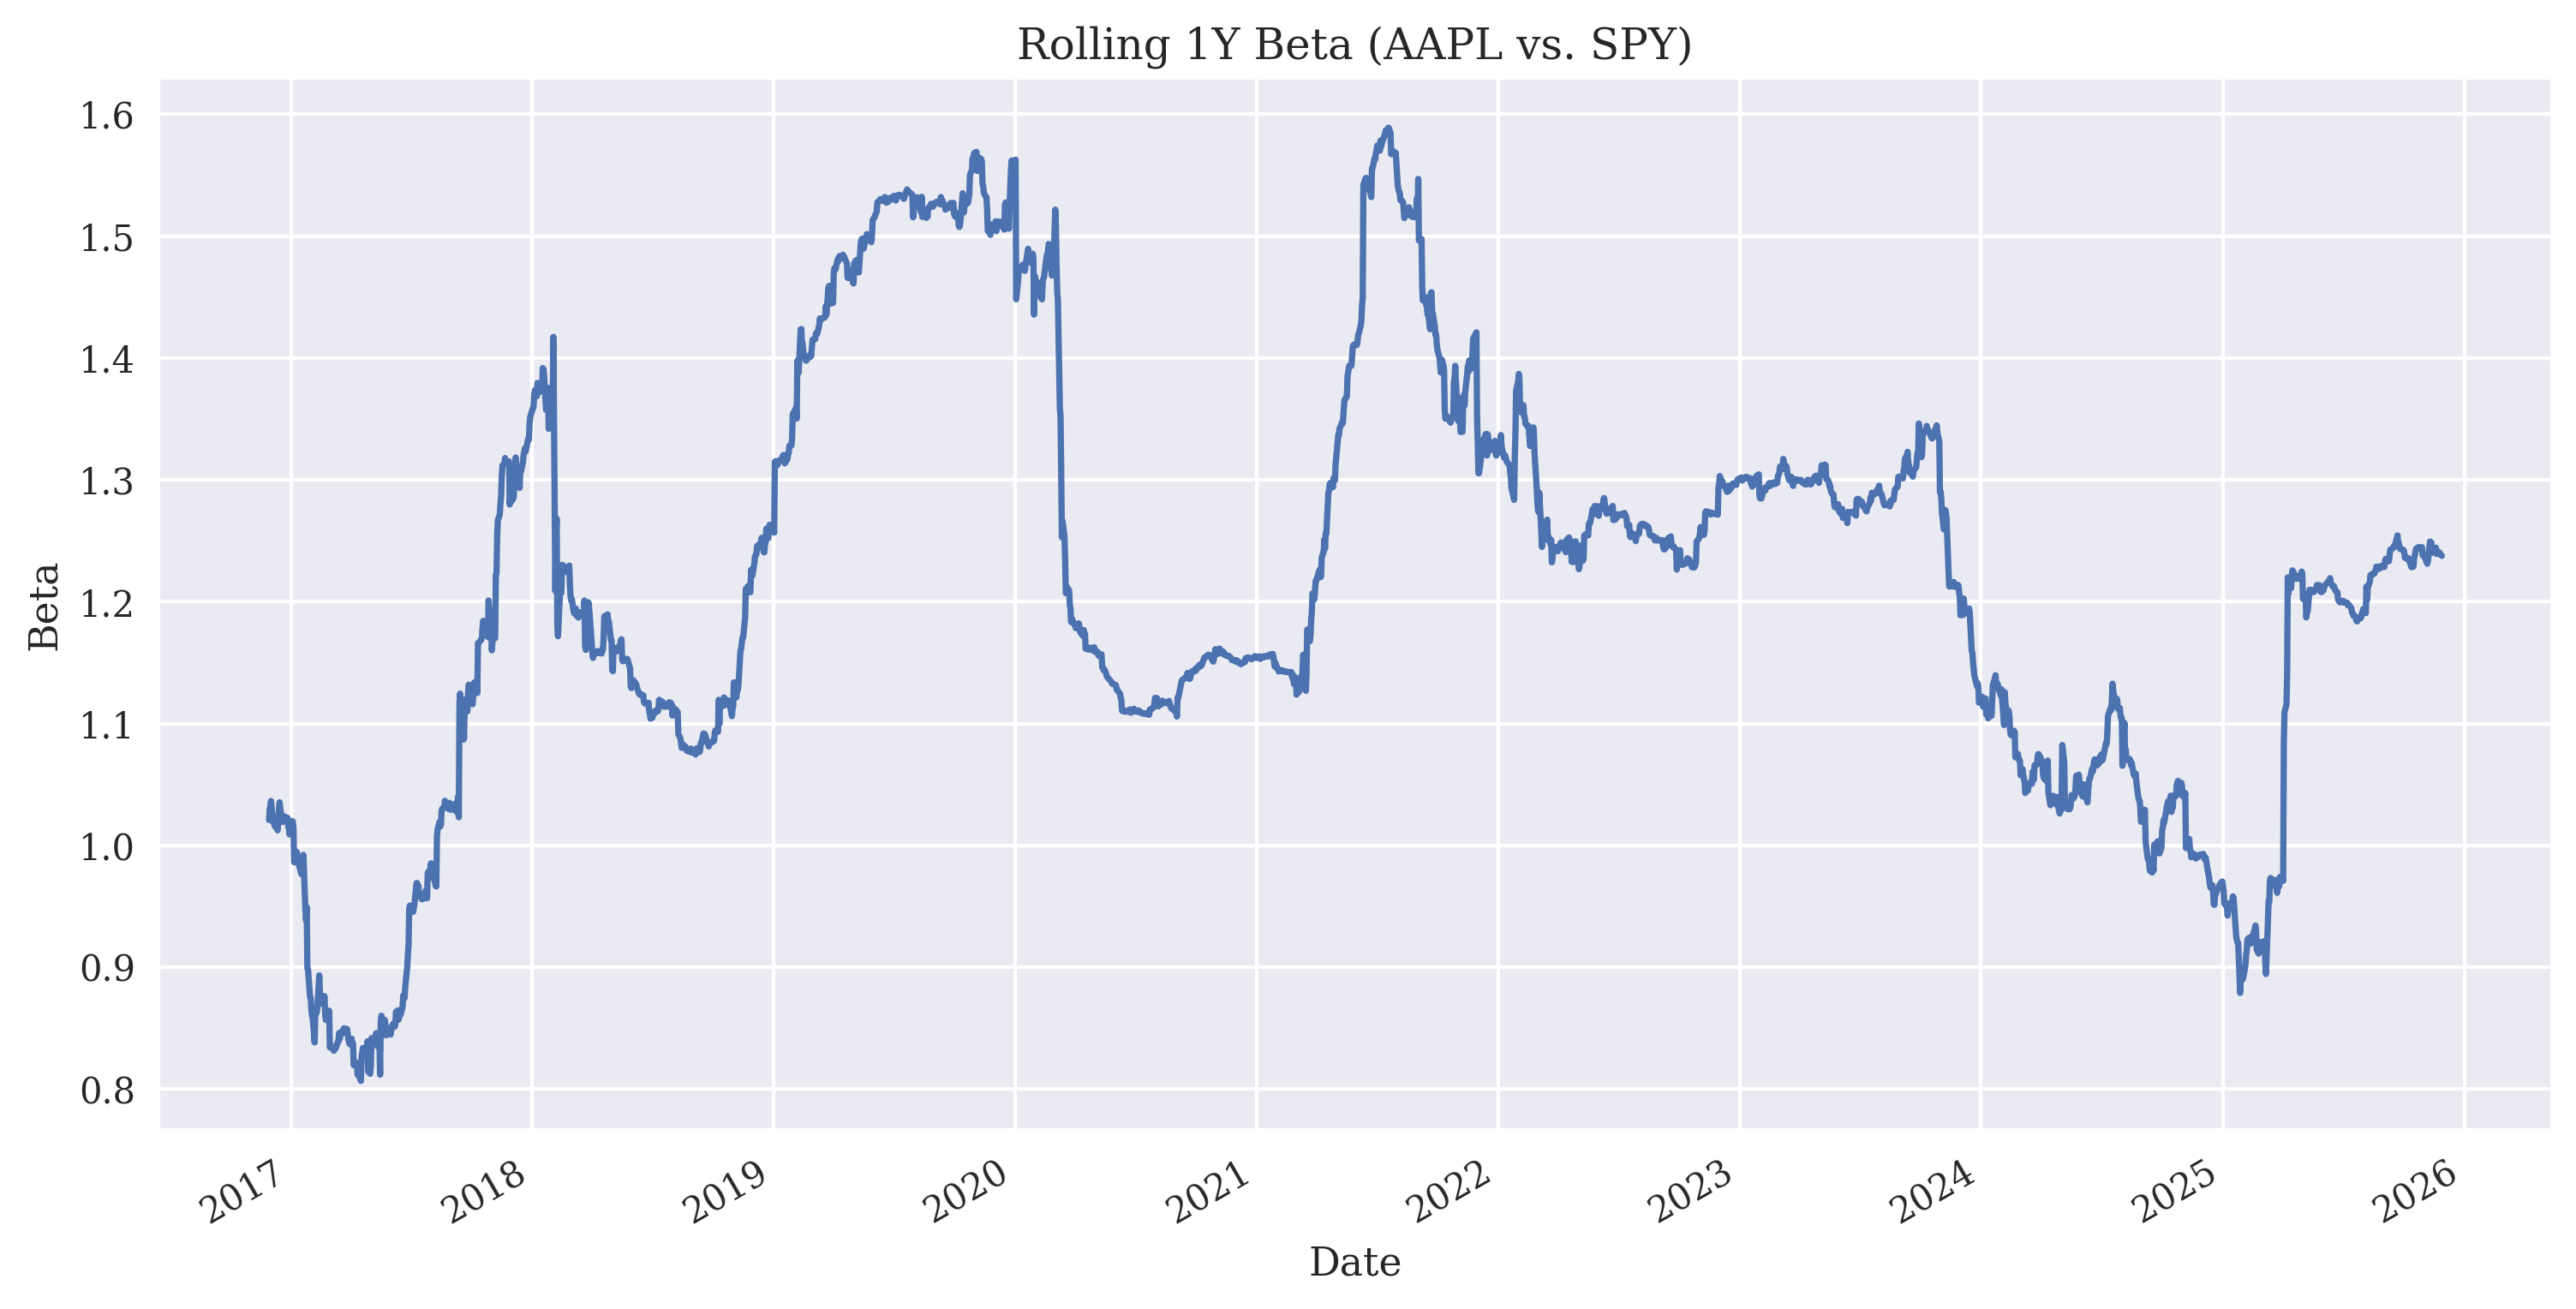

In [8]:
window = 252
cov = log_rets[["AAPL", "SPY"]].rolling(window).cov().dropna()
rolling_beta = (                       # 在level=1层，抽取所有的"AAPL"有关的行，提取对应的跨时间序列["SPY"]数据。
    cov.xs("AAPL", level=1)["SPY"] /
    cov.xs("SPY", level=1)["SPY"]
)

fig, ax = plt.subplots(figsize=(12, 6))
rolling_beta.plot(ax=ax)
ax.set_title("Rolling 1Y Beta (AAPL vs. SPY)")
ax.set_ylabel("Beta")
plt.show()

In [9]:
cov

AAPL       SPY
Date                               
2016-11-29 AAPL  0.000234  0.000079
           SPY   0.000079  0.000077
2016-11-30 AAPL  0.000234  0.000079
           SPY   0.000079  0.000077
2016-12-01 AAPL  0.000234  0.000079
...                   ...       ...
2025-11-25 SPY   0.000188  0.000151
2025-11-26 AAPL  0.000414  0.000188
           SPY   0.000188  0.000152
2025-11-28 AAPL  0.000413  0.000188
           SPY   0.000188  0.000152

[4526 rows x 2 columns]

## 3. Multifactor Example
We treat <code>SPY</code>, <code>GLD</code>, and <code>TLT</code> as market, commodity, and rate factors, respectively.

In [10]:
factors = excess_rets[["SPY", "GLD", "TLT"]]  # TLT是专门买 20 年以上到期美国国债的 ETF。
asset = excess_rets["NVDA"]
X = sm.add_constant(factors)
multi_model = sm.OLS(asset, X).fit()
print(multi_model.summary())
pd.DataFrame({"param": multi_model.params, "tvalue": multi_model.tvalues})

                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     645.3
Date:                Wed, 06 May 2026   Prob (F-statistic):          6.52e-311
Time:                        12:59:15   Log-Likelihood:                 5867.2
No. Observations:                2514   AIC:                        -1.173e+04
Df Residuals:                    2510   BIC:                        -1.170e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.000      2.761      0.0

,param,tvalue
const,0.001295,2.760713
SPY,1.826683,43.615604
GLD,-0.085655,-1.623641
TLT,0.152899,2.908054


### 3.1 Factor Premia and Expected Returns
We combine estimated loadings with factor means to estimate expected returns for each asset.

In [18]:
print(excess_rets)
factors

                AAPL      NVDA       JPM       SPY       GLD       TLT  \
Date                                                                     
2015-12-01 -0.008229  0.031843  0.013772  0.009411  0.003447  0.013335   
2015-12-02 -0.009154 -0.007744 -0.014231 -0.010342 -0.015747  0.000245   
2015-12-03 -0.009410 -0.002226 -0.013065 -0.014176  0.010491 -0.027639   
2015-12-04  0.032628  0.039817  0.031190  0.019236  0.021887  0.008667   
2015-12-07 -0.006400 -0.019209 -0.013276 -0.006156 -0.013143  0.009577   
...              ...       ...       ...       ...       ...       ...   
2025-11-21  0.019410 -0.009870 -0.001287  0.009833 -0.001628  0.002942   
2025-11-24  0.016106  0.020230 -0.000146  0.014532  0.015641  0.005603   
2025-11-25  0.003719 -0.026332  0.016560  0.009283 -0.000395  0.002473   
2025-11-26  0.002013  0.013549  0.015118  0.006800  0.007887  0.004343   
2025-11-28  0.004594 -0.018330  0.017449  0.005364  0.012268 -0.004835   

              EURUSD   BTC-USD  
Date

,SPY,GLD,TLT
Date,,,
2015-12-01,0.009411,0.003447,0.013335
2015-12-02,-0.010342,-0.015747,0.000245
2015-12-03,-0.014176,0.010491,-0.027639
2015-12-04,0.019236,0.021887,0.008667
2015-12-07,-0.006156,-0.013143,0.009577
...,...,...,...
2025-11-21,0.009833,-0.001628,0.002942
2025-11-24,0.014532,0.015641,0.005603
2025-11-25,0.009283,-0.000395,0.002473


In [21]:
factor_means = factors.mean() * 252               # 每个因子的“年化预期收益”.
loadings = {}
for ticker in excess_rets.columns:
    X = sm.add_constant(factors)
    res = sm.OLS(excess_rets[ticker], X).fit()   # 对每个资产做回归.
    loadings[ticker] = res.params[1:]            # 👉 只保留 β（因子暴露）.此时index是 factors，列名是资产即ticker. 结构是：factors * tickers。

loadings_df = pd.DataFrame(loadings).T           # 👉 每个资产“对各个因子的敏感度（exposure）”. T后结构是 tickers * factors。
expected_returns = loadings_df @ factor_means    # 👉 “资产赚多少钱 = 它暴露在哪些因子 × 因子能赚多少钱”. 结构是 tickers * factors * factors。
expected_returns.head()

,0
AAPL,0.137277
NVDA,0.198219
JPM,0.113784
SPY,0.115787
GLD,0.113970


In [14]:
res.params

,0
const,0.001505
SPY,0.899611
GLD,0.403579
TLT,-0.013271


## 4. Exercises
### Exercise 1 – CAPM for Every Asset
Write a function that returns a DataFrame of alpha/beta estimates for all tickers.
<details><summary>Hint</summary>
Iterate through <code>excess_rets.columns</code>, reuse <code>regression_frame</code>, and collect <code>model.params</code> results.
</details>

### Exercise 2 – Beta vs. Volatility Plot
Plot beta on the x-axis and annualized volatility on the y-axis for each asset, labeling points.
<details><summary>Hint</summary>
Use the alpha/beta table from Exercise 1 and combine with <code>log_rets.std()</code>.
</details>

### Exercise 3 – Custom Factor Set
Pick any two assets as new factors (e.g., <code>BTC-USD</code> and <code>EURUSD</code>) and rerun the multi-factor regression for <code>JPM</code>.
<details><summary>Hint</summary>
Construct <code>X = sm.add_constant(excess_rets[[factor1, factor2]])</code> and interpret coefficients.
</details>


## 5. Takeaways for Chapter 5
- pandas + statsmodels make CAPM/MF regressions turnkey.
- Rolling diagnostics reveal instability that static tables hide.
- Simple factor mixes (SPY/GLD/TLT) already show how to assemble factor-based expected returns.


<img src="https://hilpisch.com/tpq_logo_bic.png" width="20%" align="right">